# ==================================================
# HOTEL BOOKING ANALYSIS - SET B
# Phase 1.1 : Dataset Loading & Schema Audit
# ==================================================

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [65]:
DATA_PATH = Path("../data/raw/hotel_bookings (1).csv")

print(DATA_PATH)

..\data\raw\hotel_bookings (1).csv


In [66]:
df = pd.read_csv(
    DATA_PATH,
    keep_default_na=False
)

In [67]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 12000
Columns : 28


In [68]:
df.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,3,Mid-Range,40,2024-06-01,2024-08-30,2024-09-03,Deluxe,2,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,,
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,5,Mid-Range,30,2024-06-06,2024-07-01,2024-07-05,Standard,1,4,Corporate Portal,4021.62,0.00,,16086.48,Net Banking,Cancelled,,
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,3,Luxury,150,2024-02-15,2024-02-22,2024-02-25,Deluxe,2,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,3,Mid-Range,100,2024-07-10,2024-08-04,2024-08-07,Deluxe,1,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,,
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,5,Mid-Range,60,2024-10-27,2024-11-11,2024-11-18,Deluxe,2,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


In [69]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. booking_id
2. customer_id
3. customer_name
4. customer_segment
5. customer_signup_date
6. customer_home_city
7. customer_loyalty_tier
8. property_id
9. property_name
10. property_city
11. property_star_rating
12. property_type
13. property_total_rooms
14. booking_date
15. checkin_date
16. checkout_date
17. room_type
18. num_rooms
19. nights
20. booking_channel
21. adr
22. discount_amount
23. coupon_code
24. total_amount
25. payment_method
26. booking_status
27. review_rating
28. review_date


In [70]:
df.dtypes


booking_id                 int64
customer_id                int64
customer_name                str
customer_segment             str
customer_signup_date         str
customer_home_city           str
customer_loyalty_tier        str
property_id                int64
property_name                str
property_city                str
property_star_rating       int64
property_type                str
property_total_rooms       int64
booking_date                 str
checkin_date                 str
checkout_date                str
room_type                    str
num_rooms                  int64
nights                     int64
booking_channel              str
adr                      float64
discount_amount          float64
coupon_code                  str
total_amount             float64
payment_method               str
booking_status               str
review_rating                str
review_date                  str
dtype: object

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             12000 non-null  int64  
 1   customer_id            12000 non-null  int64  
 2   customer_name          12000 non-null  str    
 3   customer_segment       12000 non-null  str    
 4   customer_signup_date   12000 non-null  str    
 5   customer_home_city     12000 non-null  str    
 6   customer_loyalty_tier  12000 non-null  str    
 7   property_id            12000 non-null  int64  
 8   property_name          12000 non-null  str    
 9   property_city          12000 non-null  str    
 10  property_star_rating   12000 non-null  int64  
 11  property_type          12000 non-null  str    
 12  property_total_rooms   12000 non-null  int64  
 13  booking_date           12000 non-null  str    
 14  checkin_date           12000 non-null  str    
 15  checkout_date

In [72]:
(df == "").sum()

booking_id                  0
customer_id                 0
customer_name               0
customer_segment            0
customer_signup_date        0
customer_home_city          0
customer_loyalty_tier       0
property_id                 0
property_name               0
property_city               0
property_star_rating        0
property_type               0
property_total_rooms        0
booking_date                0
checkin_date                0
checkout_date               0
room_type                   0
num_rooms                   0
nights                      0
booking_channel             0
adr                         0
discount_amount             0
coupon_code              3894
total_amount                0
payment_method              0
booking_status              0
review_rating            6854
review_date              6854
dtype: int64

In [73]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_summary.sort_values(
    by="Unique Values",
    ascending=False
)

,Column,Unique Values
0,booking_id,12000
20,adr,11940
23,total_amount,11923
21,discount_amount,4123
2,customer_name,800
1,customer_id,800
13,booking_date,560
4,customer_signup_date,488
27,review_date,388
15,checkout_date,372


In [74]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [75]:
schema_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing": df.isna().sum().values,
    "Blank Strings": (df == "").sum().values
})

schema_summary

,Column,Data Type,Unique Values,Missing,Blank Strings
0,booking_id,int64,12000,0,0
1,customer_id,int64,800,0,0
2,customer_name,str,800,0,0
3,customer_segment,str,3,0,0
4,customer_signup_date,str,488,0,0
5,customer_home_city,str,10,0,0
6,customer_loyalty_tier,str,4,0,0
7,property_id,int64,60,0,0
8,property_name,str,56,0,0
9,property_city,str,10,0,0


In [76]:
schema_summary.to_csv(
    "../reports/tables/schema_summary.csv",
    index=False
)

# ==================================================
# Phase 1.2 - Data Quality Audit
# ==================================================

In [77]:
df_audit = df.copy()


In [78]:
date_cols = [
    "customer_signup_date",
    "booking_date",
    "checkin_date",
    "checkout_date",
    "review_date"
]

for col in date_cols:
    df_audit[col] = pd.to_datetime(
        df_audit[col],
        errors="coerce"
    )

In [79]:
df_audit[date_cols].dtypes

customer_signup_date    datetime64[us]
booking_date            datetime64[us]
checkin_date            datetime64[us]
checkout_date           datetime64[us]
review_date             datetime64[us]
dtype: object

In [80]:
##Invalid Stay Detection

invalid_stays = df_audit[
    df_audit["checkout_date"]
    <=
    df_audit["checkin_date"]
]

invalid_stays.shape[0]


120

In [81]:

invalid_stays.to_csv(
    "../reports/tables/invalid_stays.csv",
    index=False
)

In [82]:
#Booking Before Signup

booking_before_signup = df_audit[
    df_audit["booking_date"]
    <
    df_audit["customer_signup_date"]
]

booking_before_signup.shape[0]

163

In [83]:
booking_before_signup.to_csv(
    "../reports/tables/Booking_Before_Signup.csv",
    index=False
)

In [84]:
# Zero Room Bookings

zero_rooms = df_audit[
    df_audit["num_rooms"] == 0
]

zero_rooms.shape[0]

60

In [85]:
zero_rooms.to_csv(
    "../reports/tables/zero_rooms.csv",
    index=False
)

In [86]:
property_reuse = (
    df_audit.groupby("property_name")
    .agg({
        "property_city":"nunique",
        "property_id":"nunique"
    })
    .reset_index()
)
property_reused= property_reuse[
    property_reuse["property_city"] > 1
]

In [87]:
property_reused.to_csv(
    "../reports/tables/property_reuse.csv",
    index=False
)

In [88]:
cancelled_reviews = df_audit[
    (df_audit["booking_status"] == "Cancelled")
    &
    (df["review_rating"] != "")
]
cancelled_reviews.shape[0]

50

In [89]:
cancelled_reviews.to_csv(
    "../reports/tables/cancelled_reviews.csv",
    index=False
)

In [90]:
df_audit.groupby(
    "customer_segment"
)["review_rating"].nunique()

customer_segment
Corporate     9
Group         6
Individual    6
Name: review_rating, dtype: int64

In [91]:
df_audit.groupby(
    "customer_segment"
)["review_rating"].unique()

customer_segment
Corporate     [, 6.0, 9.0, 7.0, 5.0, 10.0, 8.0, 4.0, 3.0]
Group                         [, 4.0, 2.0, 5.0, 3.0, 1.0]
Individual                    [, 3.0, 2.0, 5.0, 4.0, 1.0]
Name: review_rating, dtype: object

In [92]:
df["coupon_code"].value_counts(
    dropna=False
)


coupon_code
NONE       3978
           3894
APPDEAL    1087
SAVE10     1061
WELCOME    1005
FEST15      975
Name: count, dtype: int64

In [93]:
df["customer_loyalty_tier"].value_counts(
    dropna=False
)

customer_loyalty_tier
None        5571
Silver      3135
Gold        2100
Platinum    1194
Name: count, dtype: int64

In [94]:
# ==================================================
# Data Quality Audit Summary
# ==================================================

audit_summary = pd.DataFrame({
    "Issue": [
        "Invalid Stay Dates",
        "Booking Before Signup",
        "Zero Room Bookings",
        "Property Names Reused Across Cities",
        "Cancelled Bookings With Reviews"
    ],
    "Count": [
        invalid_stays.shape[0],
        booking_before_signup.shape[0],
        zero_rooms.shape[0],
        property_reuse[property_reuse["property_city"] > 1].shape[0],
        cancelled_reviews.shape[0]
    ]
})

# Percentage of total records
audit_summary["Percentage"] = (
    audit_summary["Count"] / len(df_audit) * 100
).round(2)

audit_summary

,Issue,Count,Percentage
0,Invalid Stay Dates,120,1.00
1,Booking Before Signup,163,1.36
2,Zero Room Bookings,60,0.50
3,Property Names Reused Across Cities,4,0.03
4,Cancelled Bookings With Reviews,50,0.42


In [95]:
audit_summary.to_csv(
    "../reports/tables/data_quality_audit.csv",
    index=False
)

print("Audit summary exported successfully.")


Audit summary exported successfully.


# ==================================================
# Phase 1.3 - Data Preparation for Analysis
# ==================================================

In [96]:
# ==================================================
# Create Analytical Dataset
# ==================================================

df_clean = df_audit.copy()

print(df_clean.shape)

(12000, 28)


In [97]:
df_clean["review_rating"] = (
    df_clean["review_rating"]
    .replace("", np.nan)
)

df_clean["review_rating"] = pd.to_numeric(
    df_clean["review_rating"],
    errors="coerce"
)

In [98]:
df_clean["normalized_review_rating"] = np.where(
    df_clean["customer_segment"] == "Corporate",
    (df_clean["review_rating"] / 10) * 5,
    df_clean["review_rating"]
)

In [99]:
df_clean[
    [
        "customer_segment",
        "review_rating",
        "normalized_review_rating"
    ]
].sample(10)

,customer_segment,review_rating,normalized_review_rating
3743,Corporate,NaN,NaN
10844,Individual,5.0,5.0
6183,Individual,NaN,NaN
6455,Group,NaN,NaN
4290,Individual,3.0,3.0
395,Individual,4.0,4.0
9486,Individual,4.0,4.0
3931,Corporate,9.0,4.5
7802,Individual,NaN,NaN
9219,Individual,4.0,4.0


In [100]:
df_clean["coupon_used"] = ~(
    (df_clean["coupon_code"] == "")
    |
    (df_clean["coupon_code"] == "NONE")
)

In [120]:
df_clean["coupon_used"].value_counts()

coupon_used
False    7872
True     4128
Name: count, dtype: int64

In [101]:
customer_booking_counts = (
    df_clean["customer_id"]
    .value_counts()
)

In [102]:
df_clean["customer_total_bookings"] = (
    df_clean["customer_id"]
    .map(customer_booking_counts)
)

In [103]:
df_clean["repeat_customer"] = (
    df_clean["customer_total_bookings"] > 1
)

In [104]:
df_clean[
    [
        "customer_id",
        "customer_total_bookings",
        "repeat_customer"
    ]
].head()

,customer_id,customer_total_bookings,repeat_customer
0,424,12,True
1,239,16,True
2,301,14,True
3,722,12,True
4,306,13,True


In [105]:
df_clean["gross_revenue"] = (
    df_clean["total_amount"]
    +
    df_clean["discount_amount"]
)

In [106]:
df_clean["realized_revenue"] = np.where(
    df_clean["booking_status"] == "Completed",
    df_clean["total_amount"],
    0
)

In [123]:
df_clean["realized_revenue"].sum()

np.float64(294859791.61)

In [108]:
df_clean["discount_pct"] = np.where(
    df_clean["gross_revenue"] > 0,
    (
        df_clean["discount_amount"]
        /
        df_clean["gross_revenue"]
    ) * 100,
    np.nan
)

In [124]:
df_clean["discount_pct"].describe()

count    11960.000000
mean         5.338289
std          8.775113
min          0.000000
25%          0.000000
50%          0.000000
75%         11.400177
max        100.000000
Name: discount_pct, dtype: float64

In [110]:
df_clean["per_room_amount"] = np.where(
    df_clean["num_rooms"] > 0,
    (
        df_clean["total_amount"]
        /
        df_clean["num_rooms"]
    ),
    np.nan
)

In [111]:
df_clean["per_room_amount"].describe()

count     11940.000000
mean      21766.070334
std       24339.960415
min        1238.550000
25%        7634.565000
50%       13884.145000
75%       26466.067500
max      359708.165000
Name: per_room_amount, dtype: float64

In [112]:
df_clean["calculated_nights"] = (
    df_clean["checkout_date"]
    -
    df_clean["checkin_date"]
).dt.days

In [115]:
(
    df_clean["calculated_nights"]
    !=
    df_clean["nights"]
).sum()

np.int64(120)

In [116]:
analysis_df = df_clean[
    (df_clean["booking_status"] == "Completed")
].copy()

In [119]:
analysis_df.shape

(9333, 37)

In [117]:
df_clean.to_csv(
    "../data/processed/hotel_bookings_clean.csv",
    index=False
)

print("Analytical dataset exported.")

Analytical dataset exported.


In [125]:
analysis_df.to_csv(
    "../data/processed/completed_bookings_analysis.csv",
    index=False
)

print("Completed booking dataset exported.")

Completed booking dataset exported.


# ==================================================
# Phase 1.4 - Dataset Profiling
# ==================================================

In [126]:
booking_status_dist = (
    df_clean["booking_status"]
    .value_counts()
    .reset_index()
)

booking_status_dist.columns = [
    "Booking Status",
    "Count"
]

booking_status_dist["Percentage"] = (
    booking_status_dist["Count"]
    / len(df_clean)
    * 100
).round(2)

booking_status_dist

,Booking Status,Count,Percentage
0,Completed,9333,77.78
1,Cancelled,2302,19.18
2,No-Show,365,3.04


In [127]:
booking_status_dist.to_csv(
    "../reports/tables/booking_status_distribution.csv",
    index=False
)

In [129]:
customer_segment_dist = (
    df_clean["customer_segment"]
    .value_counts()
    .reset_index()
)

customer_segment_dist.columns = [
    "Customer Segment",
    "Count"
]

customer_segment_dist["Percentage"] = (
    customer_segment_dist["Count"]
    / len(df_clean)
    * 100
).round(2)

customer_segment_dist

,Customer Segment,Count,Percentage
0,Individual,7700,64.17
1,Corporate,2892,24.10
2,Group,1408,11.73


In [130]:
customer_segment_dist.to_csv(
    "../reports/tables/customer_segment_distribution.csv",
    index=False
)

In [133]:
loyalty_dist = (
    df_clean["customer_loyalty_tier"]
    .value_counts()
    .reset_index()
)

loyalty_dist.columns = [
    "Loyalty Tier",
    "Count"
]

loyalty_dist["Percentage"] = (
    loyalty_dist["Count"]
    / len(df_clean)
    * 100
).round(2)

loyalty_dist

,Loyalty Tier,Count,Percentage
0,None,5571,46.42
1,Silver,3135,26.12
2,Gold,2100,17.50
3,Platinum,1194,9.95


In [134]:
loyalty_dist.to_csv(
    "../reports/tables/loyalty_tier_distribution.csv",
    index=False
)

In [135]:
channel_dist = (
    df_clean["booking_channel"]
    .value_counts()
    .reset_index()
)

channel_dist.columns = [
    "Booking Channel",
    "Count"
]

channel_dist["Percentage"] = (
    channel_dist["Count"]
    / len(df_clean)
    * 100
).round(2)

channel_dist

,Booking Channel,Count,Percentage
0,OTA,4245,35.38
1,Corporate Portal,3213,26.78
2,Travel Agent,2414,20.12
3,Direct Website,2128,17.73


In [136]:
channel_dist.to_csv(
    "../reports/tables/booking_channel_distribution.csv",
    index=False
)

In [137]:
property_type_dist = (
    df_clean["property_type"]
    .value_counts()
    .reset_index()
)

property_type_dist.columns = [
    "Property Type",
    "Count"
]

property_type_dist["Percentage"] = (
    property_type_dist["Count"]
    / len(df_clean)
    * 100
).round(2)

property_type_dist

,Property Type,Count,Percentage
0,Mid-Range,4749,39.57
1,Budget,3772,31.43
2,Premium,2086,17.38
3,Luxury,1393,11.61


In [138]:
property_type_dist.to_csv(
    "../reports/tables/property_type_distribution.csv",
    index=False
)

In [139]:
room_type_dist = (
    df_clean["room_type"]
    .value_counts()
    .reset_index()
)

room_type_dist.columns = [
    "Room Type",
    "Count"
]

room_type_dist["Percentage"] = (
    room_type_dist["Count"]
    / len(df_clean)
    * 100
).round(2)

room_type_dist

,Room Type,Count,Percentage
0,Standard,5939,49.49
1,Deluxe,4289,35.74
2,Suite,1772,14.77


In [143]:
booked_revenue = df_clean["total_amount"].sum()
booked_revenue

np.float64(375761751.24)

In [147]:
business_profile.to_csv(
    "../reports/tables/business_profile.csv",
    index=False
)

In [148]:
booked_revenue = df_clean["total_amount"].sum()
booked_revenue

np.float64(375761751.24)

In [149]:
realized_revenue = df_clean["realized_revenue"].sum()
realized_revenue

np.float64(294859791.61)

In [150]:
overstatement_pct = (
    (
        booked_revenue
        - realized_revenue
    )
    /
    booked_revenue
    * 100
)

print(
    f"Revenue Overstatement = {overstatement_pct:.2f}%"
)

Revenue Overstatement = 21.53%


In [146]:
business_profile = pd.DataFrame({
    "Metric": [
        "Total Bookings",
        "Unique Customers",
        "Unique Properties",
        "Realized Revenue",
        "Booked Revenue",
        "Coupon Bookings",
        "No-Coupon Bookings"
    ],
    "Value": [
        len(df_clean),
        df_clean["customer_id"].nunique(),
        df_clean["property_id"].nunique(),
        round(df_clean["realized_revenue"].sum(), 2),
        round(df_clean["total_amount"].sum(), 2),
        df_clean["coupon_used"].sum(),
        (~df_clean["coupon_used"]).sum()
    ]
})

business_profile

,Metric,Value
0,Total Bookings,1.200000e+04
1,Unique Customers,8.000000e+02
2,Unique Properties,6.000000e+01
3,Realized Revenue,2.948598e+08
4,Booked Revenue,3.757618e+08
5,Coupon Bookings,4.128000e+03
6,No-Coupon Bookings,7.872000e+03


In [140]:
room_type_dist.to_csv(
    "../reports/tables/room_type_distribution.csv",
    index=False
)

# ==================================================
# Section 2 - Discount Erosion Case Study
# B1 - Discount Landscape
# ==================================================

In [152]:
channel_discount = (
    analysis_df
    .groupby("booking_channel")
    .agg(
        completed_bookings=("booking_id","count"),
        gross_revenue=("gross_revenue","sum"),
        discount_amount=("discount_amount","sum"),
        realized_revenue=("realized_revenue","sum")
    )
    .reset_index()
)

In [153]:
channel_discount["discount_intensity_pct"] = (
    channel_discount["discount_amount"]
    /
    channel_discount["gross_revenue"]
    * 100
)

In [154]:
channel_discount = channel_discount.round(2)

In [155]:
channel_discount.sort_values(
    "discount_intensity_pct",
    ascending=False
)

,booking_channel,completed_bookings,gross_revenue,discount_amount,realized_revenue,discount_intensity_pct
2,OTA,3180,1.069172e+08,7809779.10,99107449.63,7.30
3,Travel Agent,1948,6.356743e+07,2803263.89,60764166.35,4.41
1,Direct Website,1748,5.738372e+07,2520293.24,54863426.91,4.39
0,Corporate Portal,2457,8.358629e+07,3461545.37,80124748.72,4.14


In [156]:
platform_discount_intensity = (
    analysis_df["discount_amount"].sum()
    /
    analysis_df["gross_revenue"].sum()
    * 100
)

print(
    f"Platform Discount Intensity: "
    f"{platform_discount_intensity:.2f}%"
)

Platform Discount Intensity: 5.33%


In [157]:
channel_discount["gap_vs_platform"] = (
    channel_discount["discount_intensity_pct"]
    -
    platform_discount_intensity
).round(2)

In [158]:
channel_discount.sort_values(
    "discount_intensity_pct",
    ascending=False
)

,booking_channel,completed_bookings,gross_revenue,discount_amount,realized_revenue,discount_intensity_pct,gap_vs_platform
2,OTA,3180,1.069172e+08,7809779.10,99107449.63,7.30,1.97
3,Travel Agent,1948,6.356743e+07,2803263.89,60764166.35,4.41,-0.92
1,Direct Website,1748,5.738372e+07,2520293.24,54863426.91,4.39,-0.94
0,Corporate Portal,2457,8.358629e+07,3461545.37,80124748.72,4.14,-1.19


In [159]:
focus_channel = (
    channel_discount
    .sort_values(
        "discount_intensity_pct",
        ascending=False
    )
    .iloc[0]["booking_channel"]
)

focus_channel

'OTA'

In [160]:
channel_discount.to_csv(
    "../reports/tables/channel_discount_analysis.csv",
    index=False
)

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

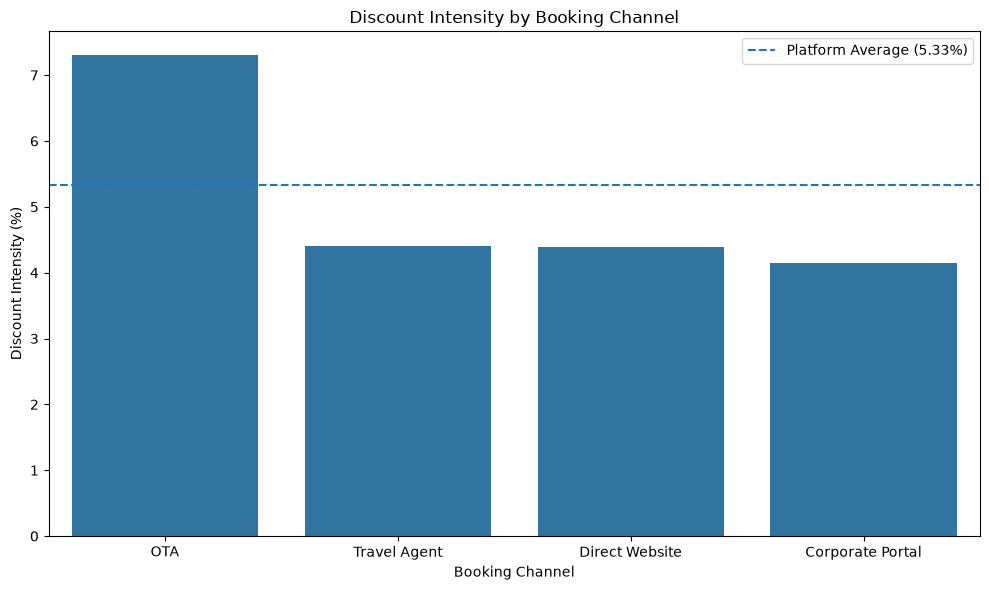

In [162]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=channel_discount.sort_values(
        "discount_intensity_pct",
        ascending=False
    ),
    x="booking_channel",
    y="discount_intensity_pct"
)

plt.axhline(
    y=platform_discount_intensity,
    linestyle="--",
    label=f"Platform Average ({platform_discount_intensity:.2f}%)"
)

plt.title(
    "Discount Intensity by Booking Channel"
)

plt.xlabel("Booking Channel")
plt.ylabel("Discount Intensity (%)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/discount_intensity_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

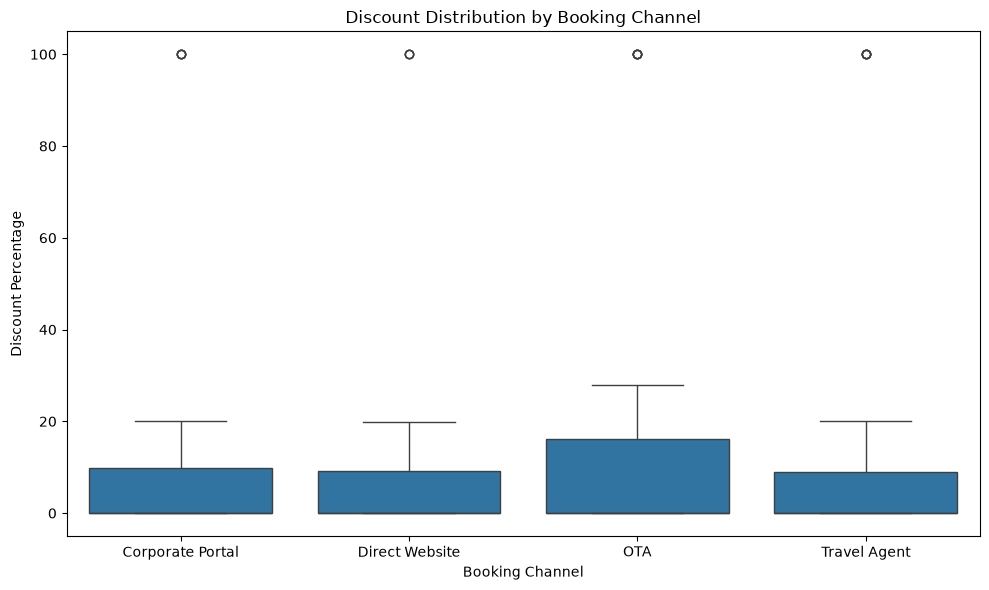

In [163]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=analysis_df,
    x="booking_channel",
    y="discount_pct"
)

plt.title(
    "Discount Distribution by Booking Channel"
)

plt.xlabel("Booking Channel")
plt.ylabel("Discount Percentage")

plt.tight_layout()

plt.savefig(
    "../reports/figures/discount_distribution_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [164]:
channel_discount.to_csv(
    "../reports/tables/section2_b1_discount_landscape.csv",
    index=False
)

# ==================================================
# Section 2 B2 - Customer Mix Analysis
# ==================================================

In [165]:
focus_df = analysis_df[
    analysis_df["booking_channel"] == focus_channel
].copy()

print(focus_df.shape)

(3180, 37)


In [166]:
ota_segment_mix = (
    focus_df["customer_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

ota_segment_mix.columns = [
    "customer_segment",
    "ota_pct"
]

In [167]:
platform_segment_mix = (
    analysis_df["customer_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

platform_segment_mix.columns = [
    "customer_segment",
    "platform_pct"
]

In [168]:
segment_mix = ota_segment_mix.merge(
    platform_segment_mix,
    on="customer_segment"
)

segment_mix["difference"] = (
    segment_mix["ota_pct"]
    -
    segment_mix["platform_pct"]
).round(2)

segment_mix

,customer_segment,ota_pct,platform_pct,difference
0,Individual,71.82,64.10,7.72
1,Corporate,14.09,24.08,-9.99
2,Group,14.09,11.83,2.26


In [169]:
segment_mix.to_csv(
    "../reports/tables/section2_b2_segment_mix.csv",
    index=False
)

In [170]:
ota_loyalty_mix = (
    focus_df["customer_loyalty_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

ota_loyalty_mix.columns = [
    "customer_loyalty_tier",
    "ota_pct"
]

In [171]:
platform_loyalty_mix = (
    analysis_df["customer_loyalty_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

platform_loyalty_mix.columns = [
    "customer_loyalty_tier",
    "platform_pct"
]

In [172]:
loyalty_mix = ota_loyalty_mix.merge(
    platform_loyalty_mix,
    on="customer_loyalty_tier"
)

loyalty_mix["difference"] = (
    loyalty_mix["ota_pct"]
    -
    loyalty_mix["platform_pct"]
).round(2)

loyalty_mix

,customer_loyalty_tier,ota_pct,platform_pct,difference
0,None,43.33,45.15,-1.82
1,Silver,25.94,25.99,-0.05
2,Gold,19.53,18.05,1.48
3,Platinum,11.19,10.80,0.39


In [173]:
loyalty_mix.to_csv(
    "../reports/tables/section2_b2_loyalty_mix.csv",
    index=False
)

In [174]:
ota_city_mix = (
    focus_df["customer_home_city"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

ota_city_mix.columns = [
    "customer_home_city",
    "ota_pct"
]

In [175]:
platform_city_mix = (
    analysis_df["customer_home_city"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

platform_city_mix.columns = [
    "customer_home_city",
    "platform_pct"
]

In [176]:
city_mix = ota_city_mix.merge(
    platform_city_mix,
    on="customer_home_city"
)

city_mix["difference"] = (
    city_mix["ota_pct"]
    -
    city_mix["platform_pct"]
).round(2)

city_mix = city_mix.sort_values(
    "ota_pct",
    ascending=False
)

city_mix.head(10)

,customer_home_city,ota_pct,platform_pct,difference
0,Chennai,12.01,11.98,0.03
1,Bangalore,11.98,11.19,0.79
2,Manali,11.70,11.84,-0.14
3,Delhi,11.51,12.15,-0.64
4,Goa,9.94,9.72,0.22
5,Kochi,9.28,8.71,0.57
6,Pune,9.15,8.70,0.45
7,Udaipur,8.58,8.68,-0.10
8,Jaipur,8.18,8.88,-0.70
9,Mumbai,7.67,8.15,-0.48


In [177]:
city_mix.to_csv(
    "../reports/tables/section2_b2_city_mix.csv",
    index=False
)

# ==================================================
# Section 2 B3
# ==================================================

In [178]:
ota_df = analysis_df[
    analysis_df["booking_channel"] == "OTA"
].copy()

print(ota_df.shape)

(3180, 37)


In [179]:
ota_df = ota_df.sort_values(
    ["customer_id", "booking_date"]
)

In [180]:
ota_df["booking_sequence"] = (
    ota_df.groupby("customer_id")
    .cumcount()
    + 1
)

In [181]:
ota_df["repeat_booking"] = (
    ota_df["booking_sequence"] > 1
)

In [182]:
ota_df["repeat_booking"].value_counts()

repeat_booking
True     2397
False     783
Name: count, dtype: int64

In [183]:
ota_full = df_clean[
    df_clean["booking_channel"] == "OTA"
].copy()

In [184]:
cancellation_rate = (
    ota_full
    .groupby("coupon_used")
    ["booking_status"]
    .apply(
        lambda x: (
            x == "Cancelled"
        ).mean() * 100
    )
    .reset_index()
)

cancellation_rate.columns = [
    "coupon_used",
    "cancellation_rate_pct"
]

cancellation_rate

,coupon_used,cancellation_rate_pct
0,False,22.277580
1,True,21.672474


In [185]:
per_room_amount = (
    ota_df[
        ota_df["num_rooms"] > 0
    ]
    .groupby("coupon_used")
    ["per_room_amount"]
    .mean()
    .reset_index()
)

per_room_amount.columns = [
    "coupon_used",
    "avg_per_room_amount"
]

per_room_amount

,coupon_used,avg_per_room_amount
0,False,23209.551346
1,True,20086.522480


In [186]:
repeat_rate = (
    ota_df
    .groupby("coupon_used")
    ["repeat_booking"]
    .mean()
    .mul(100)
    .reset_index()
)

repeat_rate.columns = [
    "coupon_used",
    "repeat_rate_pct"
]

repeat_rate

,coupon_used,repeat_rate_pct
0,False,76.097328
1,True,73.985240


In [187]:
coupon_effectiveness = (
    cancellation_rate
    .merge(
        per_room_amount,
        on="coupon_used"
    )
    .merge(
        repeat_rate,
        on="coupon_used"
    )
)

coupon_effectiveness

,coupon_used,cancellation_rate_pct,avg_per_room_amount,repeat_rate_pct
0,False,22.277580,23209.551346,76.097328
1,True,21.672474,20086.522480,73.985240


In [188]:
coupon_effectiveness.to_csv(
    "../reports/tables/section2_b3_coupon_effectiveness.csv",
    index=False
)

In [189]:
plot_df = coupon_effectiveness.copy()

plot_df["coupon_group"] = (
    plot_df["coupon_used"]
    .map({
        True: "Coupon",
        False: "No Coupon"
    })
)

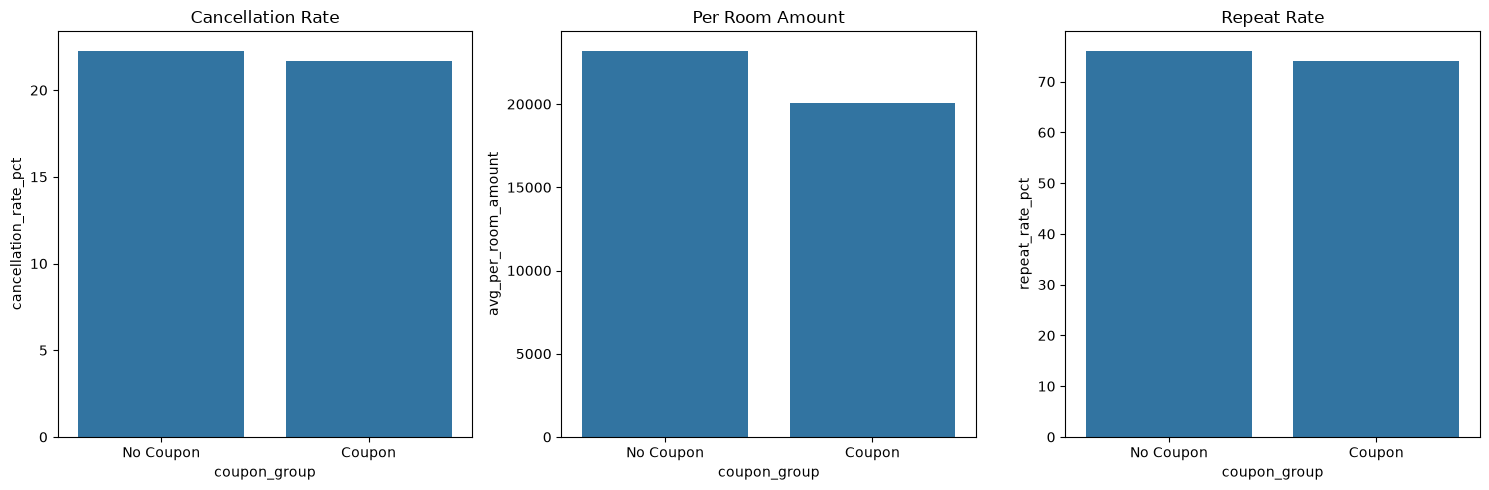

In [190]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

sns.barplot(
    data=plot_df,
    x="coupon_group",
    y="cancellation_rate_pct",
    ax=axes[0]
)

axes[0].set_title(
    "Cancellation Rate"
)

sns.barplot(
    data=plot_df,
    x="coupon_group",
    y="avg_per_room_amount",
    ax=axes[1]
)

axes[1].set_title(
    "Per Room Amount"
)

sns.barplot(
    data=plot_df,
    x="coupon_group",
    y="repeat_rate_pct",
    ax=axes[2]
)

axes[2].set_title(
    "Repeat Rate"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/03_coupon_vs_no_coupon_behavior.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [191]:
ota_coupon_analysis = (
    ota_full
    .groupby("coupon_used")
    .agg(
        bookings=("booking_id","count"),
        completed=("booking_status",
                   lambda x: (x=="Completed").sum()),
        gross_revenue=("gross_revenue","sum"),
        discount_amount=("discount_amount","sum"),
        total_amount=("total_amount","sum")
    )
    .reset_index()
)

ota_coupon_analysis

,coupon_used,bookings,completed,gross_revenue,discount_amount,total_amount
0,False,2810,2096,89463010.20,0.00,89463010.20
1,True,1435,1084,48681210.83,9721189.29,38960021.54


In [192]:
ota_coupon_analysis["discount_pct"] = (
    ota_coupon_analysis["discount_amount"]
    /
    ota_coupon_analysis["gross_revenue"]
    * 100
).round(2)

ota_coupon_analysis

,coupon_used,bookings,completed,gross_revenue,discount_amount,total_amount,discount_pct
0,False,2810,2096,89463010.20,0.00,89463010.20,0.00
1,True,1435,1084,48681210.83,9721189.29,38960021.54,19.97


In [193]:
# ==================================================
# Section 2 Summary Findings
# ==================================================

section2_summary = pd.DataFrame({
    "Analysis Area": [
        "Discount Landscape",
        "Discount Landscape",
        "Customer Mix",
        "Loyalty Mix",
        "City Mix",
        "Coupon Effectiveness",
        "Coupon Effectiveness",
        "Coupon Effectiveness",
        "Margin Recovery"
    ],

    "Finding": [
        "Platform Discount Intensity",
        "Highest Discount Channel",
        "OTA Customer Composition",
        "OTA Loyalty Composition",
        "OTA Geographic Composition",
        "Cancellation Rate Impact",
        "Per Room Amount Impact",
        "Repeat Behaviour Impact",
        "Estimated Recoverable Margin"
    ],

    "Value": [
        "5.33%",
        "OTA (7.30%)",
        "Individual travelers +7.72pp vs platform",
        "Very similar to platform",
        "Very similar to platform",
        "-0.61pp cancellation rate",
        "-13.45% per-room value",
        "-2.11pp repeat rate",
        "₹4.86 Million"
    ],

    "Business Interpretation": [
        "Overall platform discount intensity across completed bookings.",
        "OTA exceeds platform average by 1.97 percentage points.",
        "OTA attracts more price-sensitive individual travelers.",
        "Loyalty mix does not explain elevated OTA discounts.",
        "City mix does not explain elevated OTA discounts.",
        "Coupons provide only a marginal reduction in cancellations.",
        "Coupon users generate significantly lower booking value.",
        "Coupon users are less likely to be repeat customers.",
        "Reducing OTA coupon spend by 50% can recover margin with manageable risk."
    ]
})

section2_summary

,Analysis Area,Finding,Value,Business Interpretation
0,Discount Landscape,Platform Discount Intensity,5.33%,Overall platform discount intensity across com...
1,Discount Landscape,Highest Discount Channel,OTA (7.30%),OTA exceeds platform average by 1.97 percentag...
2,Customer Mix,OTA Customer Composition,Individual travelers +7.72pp vs platform,OTA attracts more price-sensitive individual t...
3,Loyalty Mix,OTA Loyalty Composition,Very similar to platform,Loyalty mix does not explain elevated OTA disc...
4,City Mix,OTA Geographic Composition,Very similar to platform,City mix does not explain elevated OTA discounts.
5,Coupon Effectiveness,Cancellation Rate Impact,-0.61pp cancellation rate,Coupons provide only a marginal reduction in c...
6,Coupon Effectiveness,Per Room Amount Impact,-13.45% per-room value,Coupon users generate significantly lower book...
7,Coupon Effectiveness,Repeat Behaviour Impact,-2.11pp repeat rate,Coupon users are less likely to be repeat cust...
8,Margin Recovery,Estimated Recoverable Margin,₹4.86 Million,Reducing OTA coupon spend by 50% can recover m...


In [194]:
section2_summary.to_csv(
    "../reports/tables/section2_summary_findings.csv",
    index=False
)

print("Section 2 summary exported successfully.")

Section 2 summary exported successfully.


# ==================================================
# Section 3 - SQL Challenge
# ==================================================

# Section 3 - SQL Challenge

## Normalized Schema Design

Tables Created:

1. customers
2. properties
3. bookings
4. reviews

Primary Keys:
- customer_id
- property_id
- booking_id

Foreign Keys:
- bookings.customer_id → customers.customer_id
- bookings.property_id → properties.property_id
- reviews.booking_id → bookings.booking_id

Constraint:
CHECK (checkout_date > checkin_date)

Index:
booking_date

In [197]:
# B-Q1 Validation in Pandas

bq1_validation = (
    analysis_df
    .groupby(
        ["property_type", "room_type"]
    )
    .size()
    .reset_index(name="completed_bookings")
)

bq1_validation["rank"] = (
    bq1_validation
    .groupby("property_type")["completed_bookings"]
    .rank(
        method="dense",
        ascending=False
    )
)

bq1_validation = bq1_validation[
    bq1_validation["rank"] == 1
]

bq1_validation.sort_values(
    "property_type"
)

,property_type,room_type,completed_bookings,rank
1,Budget,Standard,1480,1.0
4,Luxury,Standard,538,1.0
7,Mid-Range,Standard,1792,1.0
10,Premium,Standard,814,1.0


In [198]:
# ==================================================
# B-Q2 Validation
# Monthly Realized Revenue
# ==================================================

monthly_revenue = (
    analysis_df
    .assign(
        booking_month=analysis_df["booking_date"].dt.to_period("M")
    )
    .groupby("booking_month")
    ["realized_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["cumulative_revenue"] = (
    monthly_revenue["realized_revenue"]
    .cumsum()
)

monthly_revenue

,booking_month,realized_revenue,cumulative_revenue
0,2021-10,20542.57,2.054257e+04
1,2021-11,112489.90,1.330325e+05
2,2021-12,112073.50,2.451060e+05
3,2022-01,61254.07,3.063600e+05
4,2022-02,133000.69,4.393607e+05
5,2022-03,197592.43,6.369532e+05
6,2022-04,42994.83,6.799480e+05
7,2022-05,472773.01,1.152721e+06
8,2022-06,3897.98,1.156619e+06
9,2022-07,98309.91,1.254929e+06


In [199]:
monthly_revenue.to_csv(
    "../reports/tables/section3_bq2_monthly_revenue.csv",
    index=False
)

In [200]:
# ==================================================
# Section 3 Summary Findings
# ==================================================

section3_summary = pd.DataFrame({
    "Component": [
        "Schema Design",
        "Normalization",
        "Primary Keys",
        "Foreign Keys",
        "Constraint",
        "Index",
        "B-Q1 Result",
        "B-Q2 Objective"
    ],

    "Implementation": [
        "4-table relational schema",
        "Customers, Properties, Bookings, Reviews",
        "customer_id, property_id, booking_id",
        "Customer→Bookings, Property→Bookings, Booking→Reviews",
        "CHECK(checkout_date > checkin_date)",
        "booking_date",
        "Most booked room type by property type using DENSE_RANK()",
        "Monthly realized revenue and cumulative revenue using window functions"
    ],

    "Business Justification": [
        "Separates entities and reduces redundancy",
        "Improves data consistency and scalability",
        "Ensures entity uniqueness",
        "Maintains referential integrity",
        "Prevents invalid stay records",
        "Optimizes time-based analytical queries",
        "Identifies room preferences across property categories",
        "Tracks revenue growth trends over time"
    ]
})

section3_summary

,Component,Implementation,Business Justification
0,Schema Design,4-table relational schema,Separates entities and reduces redundancy
1,Normalization,"Customers, Properties, Bookings, Reviews",Improves data consistency and scalability
2,Primary Keys,"customer_id, property_id, booking_id",Ensures entity uniqueness
3,Foreign Keys,"Customer→Bookings, Property→Bookings, Booking→...",Maintains referential integrity
4,Constraint,CHECK(checkout_date > checkin_date),Prevents invalid stay records
5,Index,booking_date,Optimizes time-based analytical queries
6,B-Q1 Result,Most booked room type by property type using D...,Identifies room preferences across property ca...
7,B-Q2 Objective,Monthly realized revenue and cumulative revenu...,Tracks revenue growth trends over time


In [201]:
section3_summary.to_csv(
    "../reports/tables/section3_summary_findings.csv",
    index=False
)

print("Section 3 summary exported successfully.")

Section 3 summary exported successfully.


In [202]:
section3_conclusion = pd.DataFrame({
    "Area": [
        "Schema Design",
        "Constraint",
        "Index",
        "B-Q1",
        "B-Q2"
    ],
    "Conclusion": [
        "Normalized 4-table schema reduces redundancy and improves maintainability.",
        "CHECK(checkout_date > checkin_date) prevents invalid stay records.",
        "booking_date index improves time-series query performance.",
        "Standard rooms are the most booked room type across all property categories.",
        "Window functions enable efficient cumulative revenue analysis."
    ]
})

section3_conclusion.to_csv(
    "../reports/tables/section3_conclusion.csv",
    index=False
)

section3_conclusion

,Area,Conclusion
0,Schema Design,Normalized 4-table schema reduces redundancy a...
1,Constraint,CHECK(checkout_date > checkin_date) prevents i...
2,Index,booking_date index improves time-series query ...
3,B-Q1,Standard rooms are the most booked room type a...
4,B-Q2,Window functions enable efficient cumulative r...


# ==================================================
# Section 4 - Holiday Proximity Demand Tagger
# ==================================================


In [203]:
# Use clean dataset

holiday_df = df_clean.copy()

print(holiday_df.shape)

(12000, 37)


In [204]:
holiday_df[
    [
        "checkin_date",
        "checkout_date",
        "booking_date"
    ]
].dtypes

checkin_date     datetime64[us]
checkout_date    datetime64[us]
booking_date     datetime64[us]
dtype: object

In [205]:
holiday_df["year"] = (
    holiday_df["checkin_date"]
    .dt.year
)

holiday_df["year"].value_counts()

year
2024    12000
Name: count, dtype: int64

# ==================================================
# Holiday Tagging
# ==================================================

In [214]:
# ==================================================
# Holiday Dates (Notebook Analysis Version)
# ==================================================

holiday_dates = pd.to_datetime([
    "2024-01-26",  # Republic Day
    "2024-03-29",  # Good Friday
    "2024-08-15",  # Independence Day
    "2024-10-02",  # Gandhi Jayanti
    "2024-11-01",  # Diwali
    "2024-12-25"   # Christmas
])

holiday_dates = pd.Series(holiday_dates)

print(f"{len(holiday_dates)} holidays loaded.")
holiday_dates

6 holidays loaded.


0   2024-01-26
1   2024-03-29
2   2024-08-15
3   2024-10-02
4   2024-11-01
5   2024-12-25
dtype: datetime64[us]

In [215]:
# ==================================================
# Holiday Distance Function
# ==================================================

def nearest_holiday_distance(checkin_date):
    return min(
        abs((checkin_date - holiday).days)
        for holiday in holiday_dates
    )

In [216]:
# ==================================================
# Apply Holiday Tagging
# ==================================================

holiday_df = df_clean.copy()

holiday_df["days_from_holiday"] = (
    holiday_df["checkin_date"]
    .apply(nearest_holiday_distance)
)

holiday_df["holiday_adjacent"] = (
    holiday_df["days_from_holiday"] <= 2
)

holiday_df["holiday_adjacent"].value_counts()

holiday_adjacent
False    10994
True      1006
Name: count, dtype: int64

In [219]:
# ==================================================
# Holiday vs Regular Booking Analysis
# ==================================================

holiday_summary = (
    holiday_df
    .groupby("holiday_adjacent")
    .agg(
        bookings=("booking_id", "count"),
        avg_booking_value=("total_amount", "mean"),
        avg_stay_length=("nights", "mean"),
        cancellation_rate=(
            "booking_status",
            lambda x: (x == "Cancelled").mean() * 100
        )
    )
    .reset_index()
)

holiday_summary = holiday_summary.round(2)

holiday_summary

,holiday_adjacent,bookings,avg_booking_value,avg_stay_length,cancellation_rate
0,False,10994,31327.68,2.85,18.91
1,True,1006,31158.23,2.90,22.17


In [221]:
holiday_summary.to_csv(
    "../project/holiday_tagger/holiday_summary.csv",
    index=False
)

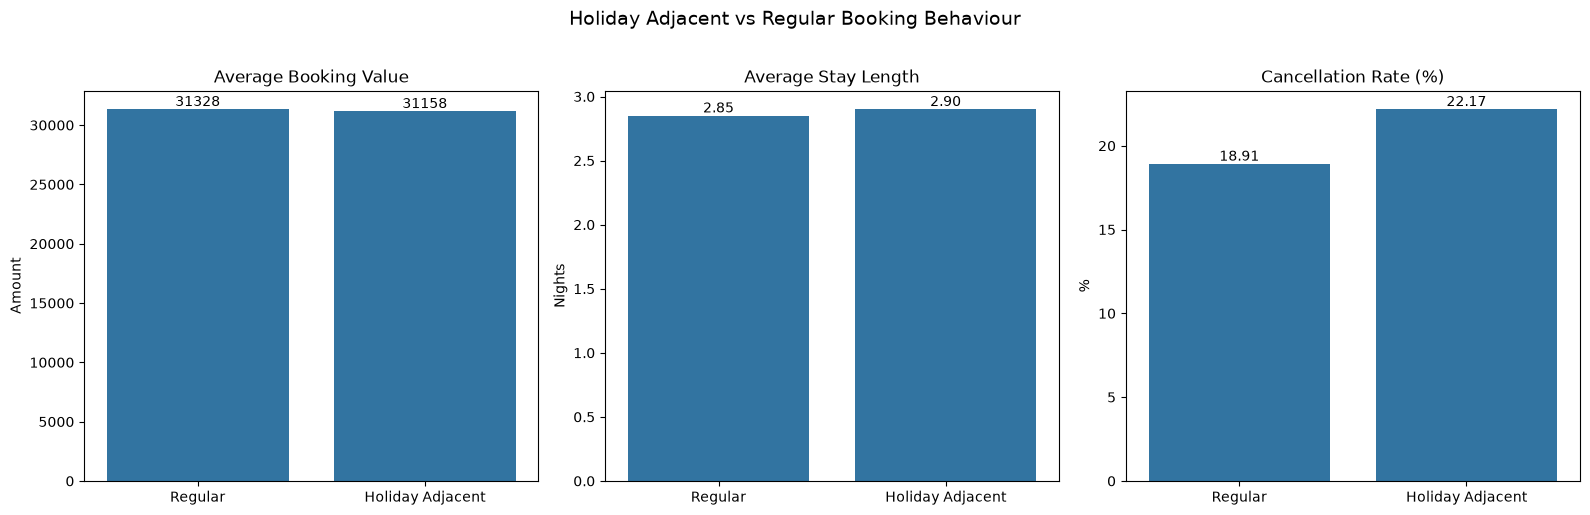

In [223]:
# ==================================================
# Visualization #4
# Holiday vs Regular Booking Behaviour
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = holiday_summary.copy()

plot_df["group"] = plot_df["holiday_adjacent"].map({
    True: "Holiday Adjacent",
    False: "Regular"
})

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

# -------------------------
# Avg Booking Value
# -------------------------
sns.barplot(
    data=plot_df,
    x="group",
    y="avg_booking_value",
    ax=axes[0]
)

axes[0].set_title("Average Booking Value")
axes[0].set_xlabel("")
axes[0].set_ylabel("Amount")

# Add labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f")

# -------------------------
# Avg Stay Length
# -------------------------
sns.barplot(
    data=plot_df,
    x="group",
    y="avg_stay_length",
    ax=axes[1]
)

axes[1].set_title("Average Stay Length")
axes[1].set_xlabel("")
axes[1].set_ylabel("Nights")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f")

# -------------------------
# Cancellation Rate
# -------------------------
sns.barplot(
    data=plot_df,
    x="group",
    y="cancellation_rate",
    ax=axes[2]
)

axes[2].set_title("Cancellation Rate (%)")
axes[2].set_xlabel("")
axes[2].set_ylabel("%")

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.2f")

plt.suptitle(
    "Holiday Adjacent vs Regular Booking Behaviour",
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/04_holiday_vs_regular_bookings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [224]:
# ==================================================
# Section 4 Summary
# ==================================================

section4_summary = holiday_summary.copy()

section4_summary["group"] = (
    section4_summary["holiday_adjacent"]
    .map({
        True: "Holiday Adjacent",
        False: "Regular"
    })
)

section4_summary = section4_summary[
    [
        "group",
        "bookings",
        "avg_booking_value",
        "avg_stay_length",
        "cancellation_rate"
    ]
]

section4_summary

,group,bookings,avg_booking_value,avg_stay_length,cancellation_rate
0,Regular,10994,31327.68,2.85,18.91
1,Holiday Adjacent,1006,31158.23,2.90,22.17


In [225]:
section4_summary.to_csv(
    "../reports/tables/section4_summary.csv",
    index=False
)

print("Section 4 summary exported.")

Section 4 summary exported.


In [226]:
# ==================================================
# Section 4 Summary Findings
# ==================================================

section4_findings = pd.DataFrame({
    "Analysis Area": [
        "Holiday Tagging",
        "Booking Value",
        "Stay Length",
        "Cancellation Behaviour",
        "Business Insight"
    ],

    "Finding": [
        "Holiday Adjacent Bookings",
        "Average Booking Value Comparison",
        "Average Stay Length Comparison",
        "Cancellation Rate Comparison",
        "Recommended Action"
    ],

    "Value": [
        "1006 bookings (8.38% of total)",
        "₹31,158 vs ₹31,328",
        "2.90 vs 2.85 nights",
        "22.17% vs 18.91%",
        "Review holiday cancellation policy"
    ],

    "Business Interpretation": [
        "Meaningful holiday segment identified using public holiday proximity.",
        "Holiday bookings do not generate materially higher booking value.",
        "Holiday travelers stay slightly longer.",
        "Holiday bookings exhibit higher cancellation risk.",
        "Stricter holiday cancellation rules may improve revenue reliability."
    ]
})

section4_findings

,Analysis Area,Finding,Value,Business Interpretation
0,Holiday Tagging,Holiday Adjacent Bookings,1006 bookings (8.38% of total),Meaningful holiday segment identified using pu...
1,Booking Value,Average Booking Value Comparison,"₹31,158 vs ₹31,328",Holiday bookings do not generate materially hi...
2,Stay Length,Average Stay Length Comparison,2.90 vs 2.85 nights,Holiday travelers stay slightly longer.
3,Cancellation Behaviour,Cancellation Rate Comparison,22.17% vs 18.91%,Holiday bookings exhibit higher cancellation r...
4,Business Insight,Recommended Action,Review holiday cancellation policy,Stricter holiday cancellation rules may improv...


In [227]:
section4_findings.to_csv(
    "../reports/tables/section4_summary_findings.csv",
    index=False
)

print("Section 4 summary exported.")


Section 4 summary exported.
